In [ ]:
import eeg_lib as eeg
import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

Device: mps


In [2]:
ds = load_dataset("DavidVivancos/MindBigData2022_MNIST_EP")

X_full, y_full = eeg.df_to_raw(ds["train"].to_pandas())
X_test_raw, y_test = eeg.df_to_raw(ds["test"].to_pandas())

print(f"Train+val: {X_full.shape}, Test: {X_test_raw.shape}")
print(f"Klasy: {np.unique(y_full)}, rozkład: {np.bincount(y_full)}")

Train+val: (51895, 14, 256), Test: (12980, 14, 256)
Klasy: [0 1 2 3 4 5 6 7 8 9], rozkład: [5212 5080 5196 5294 5079 5256 5218 5069 5241 5250]


In [3]:
X_full_raw = eeg.zscore_per_epoch(X_full)
X_test_norm = eeg.zscore_per_epoch(X_test_raw)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_full_raw, y_full, test_size=0.2, stratify=y_full, random_state=SEED)

print(f"Train: {X_train_raw.shape}, Val: {X_val_raw.shape}, Test: {X_test_norm.shape}")

Train: (41516, 14, 256), Val: (10379, 14, 256), Test: (12980, 14, 256)


In [4]:
train_loader = eeg.make_loader(X_train_raw, y_train, batch=128, shuffle=True)
val_loader = eeg.make_loader(X_val_raw, y_val, batch=256)
test_loader = eeg.make_loader(X_test_norm, y_test, batch=256)

In [5]:
import time
from pathlib import Path

print("EEGNet (Lawhern)")
eegnet = eeg.EEGNet(F1=32, D=2, F2=64, kern=32, p=0.3).to(device)
print(f"Parametry: {sum(p.numel() for p in eegnet.parameters()):,}")
eegnet, hist_egn = eeg.train_model(eegnet, train_loader, val_loader, device,
                                epochs=200, lr=5e-4, patience=40, use_augment=False, log_every=5)

timestamp = int(time.time())
folder = Path("..") / Path("models")
torch.save(eegnet.state_dict(), folder / f"eegnet_raw_{timestamp}.pth")
print(f"Model saved to {folder / f'eegnet_raw_{timestamp}.pth'}")

EEGNet (Lawhern)
Parametry: 12,490
  ep 01  train_acc=0.135  val_acc=0.163  val_f1=0.135
  ep 05  train_acc=0.181  val_acc=0.173  val_f1=0.141
  ep 10  train_acc=0.195  val_acc=0.186  val_f1=0.162
  ep 15  train_acc=0.202  val_acc=0.192  val_f1=0.169
  ep 20  train_acc=0.208  val_acc=0.199  val_f1=0.176
  ep 25  train_acc=0.212  val_acc=0.199  val_f1=0.182
  ep 30  train_acc=0.220  val_acc=0.201  val_f1=0.183
  ep 35  train_acc=0.219  val_acc=0.203  val_f1=0.186
  ep 40  train_acc=0.222  val_acc=0.204  val_f1=0.188
  ep 45  train_acc=0.223  val_acc=0.205  val_f1=0.189
  ep 50  train_acc=0.225  val_acc=0.206  val_f1=0.191
  ep 55  train_acc=0.228  val_acc=0.206  val_f1=0.194
  ep 60  train_acc=0.230  val_acc=0.205  val_f1=0.190
  ep 65  train_acc=0.230  val_acc=0.208  val_f1=0.190
  ep 70  train_acc=0.232  val_acc=0.208  val_f1=0.190
  ep 75  train_acc=0.232  val_acc=0.209  val_f1=0.195
  ep 80  train_acc=0.232  val_acc=0.206  val_f1=0.189
  ep 85  train_acc=0.234  val_acc=0.208  val_f1

EEGNet (raw)  acc=0.2075  f1=0.1934
              precision    recall  f1-score   support

           0      0.223     0.381     0.281      1304
           1      0.215     0.321     0.257      1271
           2      0.173     0.095     0.122      1299
           3      0.167     0.093     0.119      1324
           4      0.201     0.151     0.172      1270
           5      0.218     0.269     0.241      1315
           6      0.196     0.179     0.187      1305
           7      0.253     0.394     0.308      1268
           8      0.172     0.091     0.119      1311
           9      0.149     0.110     0.126      1313

    accuracy                          0.207     12980
   macro avg      0.197     0.208     0.193     12980
weighted avg      0.196     0.207     0.193     12980



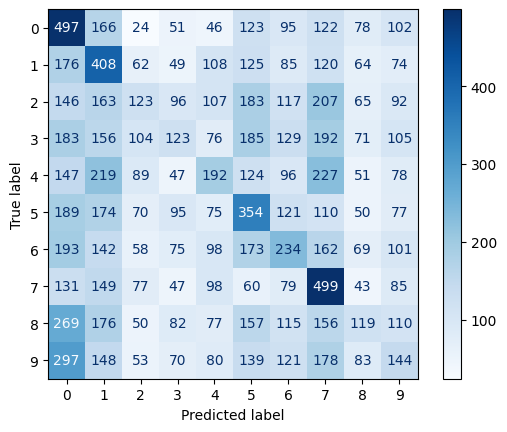

In [6]:
pred, acc, f1 = eeg.evaluate(eegnet, test_loader, device)
print(f"EEGNet (raw)  acc={acc:.4f}  f1={f1:.4f}")

print(classification_report(y_test, pred, digits=3))
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(cmap="Blues")
plt.savefig(folder / f"eegnet_raw_{timestamp}_confusion_matrix.png", bbox_inches="tight", dpi=300)

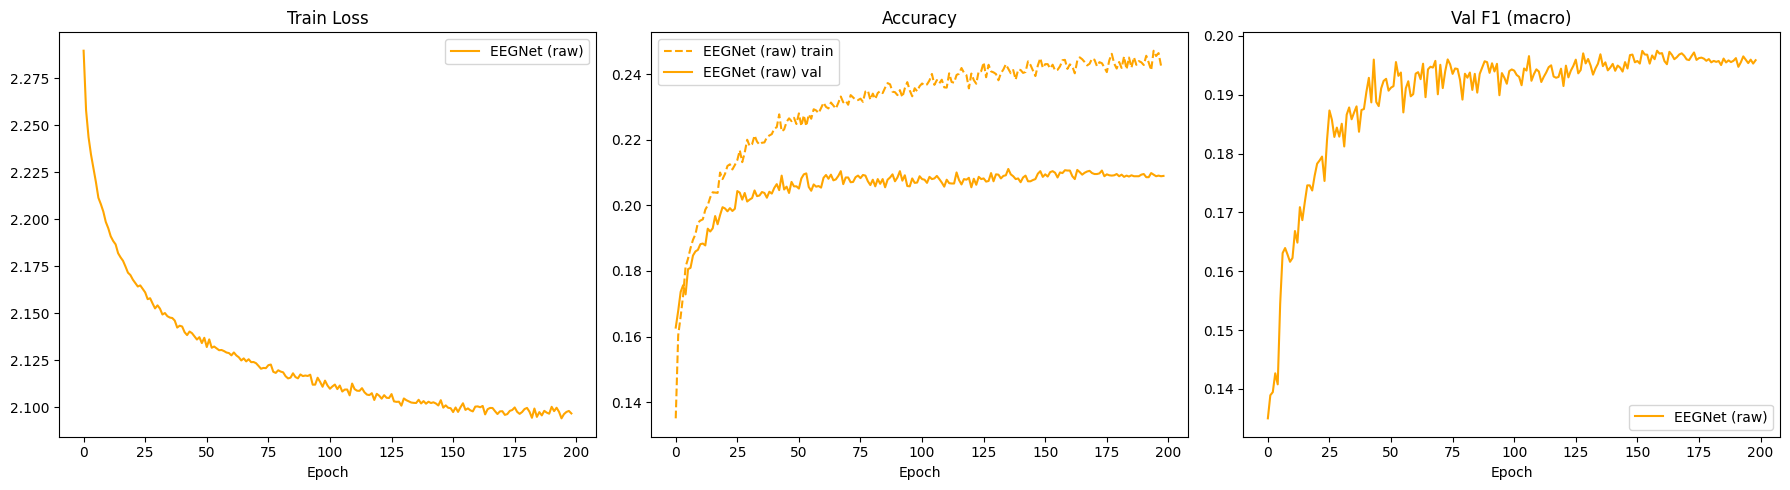

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

color = "orange"
name = "EEGNet (raw)"
axes[0].plot(hist_egn["train_loss"], label=name, color=color)
axes[1].plot(hist_egn["train_acc"], label=f"{name} train", color=color, linestyle="--")
axes[1].plot(hist_egn["val_acc"], label=f"{name} val", color=color)
axes[2].plot(hist_egn["val_f1"], label=name, color=color)

axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].set_title("Val F1 (macro)")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig(folder / f"eegnet_raw_{timestamp}_training_curves.png", bbox_inches="tight", dpi=300)
plt.show()